In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm

In [2]:
def generate_paths(S0, r, sigma, T, M, N):
    """
    Simulates underlying asset price paths for each asset with its own time-to-maturity.
        S0    : array of initial asset prices (length L)
    r     : array of risk-free rates (length L)
    sigma : array of volatilities (length L)
    T     : array of times to maturity (length L) or a scalar (in years)
    M     : number of time steps (so M+1 simulation points including time 0)
    N     : number of simulation paths

    Returns:
        paths: a NumPy array of shape (L, M+1, N)
    """
    S0 = np.atleast_1d(S0)
    r = np.atleast_1d(r)
    sigma = np.atleast_1d(sigma)
    T = np.atleast_1d(T)
    L = len(S0)

    # If T was provided as a scalar, broadcast it.
    if T.size == 1:
        T = np.full(L, T[0])

    # dt for each asset (shape: (L,))
    dt = T / M             

    # Reshape dt so it can be broadcast along time and simulation axes.
    dt_bc = dt[:, np.newaxis, np.newaxis]  # shape (L, 1, 1)

    # Generate normal variates for each asset, each time step and each path.
    Z = np.random.randn(L, M, N)

    # Compute log-increments for each asset.
    increments = (r[:, np.newaxis, np.newaxis] - 0.5 * sigma[:, np.newaxis, np.newaxis]**2) * dt_bc \
                + sigma[:, np.newaxis, np.newaxis] * np.sqrt(dt_bc) * Z
                
    # Cumulative sum gives log prices. Prepend zeros so that time0 is S0.
    logS = np.concatenate((np.zeros((L, 1, N)), np.cumsum(increments, axis=1)), axis=1)

    # Compute asset price paths.
    paths = S0[:, np.newaxis, np.newaxis] * np.exp(logS)
    return paths

def backward_induction(paths, K, r, T, M, degree=2):
    """
    Performs backward induction for the Least-Squares Monte Carlo algorithm for each asset individually.
    paths  : array with shape (L, M+1, N)
    K      : array of strike prices (length L) or scalar strike (will be broadcast)
    r      : array of risk-free rates (length L)
    T      : array of times-to-maturity (length L) or scalar (in years)
    M      : number of time steps (without the initial time point)
    degree : degree of polynomial to use in regression.

    Returns:
        prices: a 1D array of prices (one per asset) at time 0.
    """
    K = np.atleast_1d(K)
    r = np.atleast_1d(r)
    T = np.atleast_1d(T)
    L, num_steps, N = paths.shape  # note: num_steps = M+1

    # If K or T are scalar (size=1), broadcast to length L.
    if K.size == 1:
        K = np.full(L, K[0])
    if T.size == 1:
        T = np.full(L, T[0])

    prices = np.zeros(L)

    for l in range(L):
        asset_paths = paths[l, :, :]  # shape (M+1, N) for asset l
        
        # Compute dt specific to asset l.
        dt_l = T[l] / M
        # One-period discount factor for asset l.
        disc = np.exp(-r[l] * dt_l)
        
        # Cash flows at maturity for asset l.
        cashflow = np.maximum(K[l] - asset_paths[-1, :], 0)
        
        # Backward induction from t=M-1 down to t=1.
        for t in range(M-1, 0, -1):
            # Immediate exercise payoff at time t.
            immediate = np.maximum(K[l] - asset_paths[t, :], 0)
            discounted_cf = disc * cashflow
            
            # Identify in-the-money paths.
            itm = immediate > 0
            if np.any(itm):
                X = asset_paths[t, :][itm]  # underlying asset prices (for ITM paths)
                Y = discounted_cf[itm]      # discounted continuation values
                if len(X) > degree:
                    poly = np.polyfit(X, Y, degree)
                    cont_estimate = np.polyval(poly, X)
                else:
                    cont_estimate = np.zeros_like(X)
                # Determine if early exercise is optimal.
                exercise = immediate[itm] > cont_estimate
                indices = np.where(itm)[0]
                cashflow[indices[exercise]] = immediate[indices[exercise]]
                cashflow[indices[~exercise]] = discounted_cf[indices[~exercise]]
            # Discount cashflow one period backward.
            cashflow = disc * cashflow
        
        # Finally, discount from time point 1 to 0.
        price_asset = np.mean(cashflow) * np.exp(-r[l] * dt_l)
        prices[l] = price_asset
        
    return prices

def american_put_lsm(S0, K, r, sigma, T, M=50, N=100000, degree=2):
    S0 = np.atleast_1d(S0)
    K = np.atleast_1d(K)
    r = np.atleast_1d(r)
    sigma = np.atleast_1d(sigma)
    T = np.atleast_1d(T)

    # Broadcast scalar inputs to match number of assets if necessary.
    L = len(S0)
    if K.size == 1:
        K = np.full(L, K[0])
    if T.size == 1:
        T = np.full(L, T[0])

    paths = generate_paths(S0, r, sigma, T, M, N)
    return backward_induction(paths, K, r, T, M, degree)

# Example Usage
S0 = np.array([100, 200])  # Initial stock price for a single asset
K = [100, 190]  # Strike price
r = np.array([0.05, 0.05])  # Risk-free rate (annualized)
sigma = np.array([0.2, 0.2])  # Volatility (annualized)
T = [1, 0.5]  # Time to maturity (in years)
M = 50  # Number of time steps
N = 100000  # Number of simulated paths
degree = 2  # Polynomial degree for regression
price = american_put_lsm(S0, K, r, sigma, T)
print(f"LSM American Put Prices: ", price)


LSM American Put Prices:  [5.94608674 5.19927903]


In [ ]:
def generate_paths(S0, r, sigma, T, M, N):
    dt = T / M
    Z = np.random.randn(M, N)  # Normal random variables
    increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.cumsum(increments, axis=0)
    paths = S0 * np.exp(log_paths)
    paths = np.vstack([np.full(N, S0), paths])  # Add initial stock price
    return paths

def backward_induction(paths, K, r, T, M, degree=2):
    dt = T / M
    discount = np.exp(-r * dt)
    cashflows = np.maximum(K - paths[-1], 0)  # Final payoffs at maturity

    for t in range(M - 1, 0, -1):  # Work backwards
        in_the_money = np.where(paths[t] < K)[0]  # Find ITM paths
        if len(in_the_money) == 0:
            continue

        X = paths[t, in_the_money]  # Stock prices at time t
        Y = cashflows[in_the_money] * discount  # Discounted future payoffs

        # Polynomial regression for continuation value
        poly = np.polyfit(X, Y, degree)
        continuation_value = np.polyval(poly, X)

        # Early exercise decision
        exercise_value = K - X
        exercise = exercise_value > continuation_value
        cashflows[in_the_money[exercise]] = exercise_value[exercise]

    return np.mean(cashflows) * discount  # Discount to present value

def american_put_lsm(S0, K, r, sigma, T, M=50, N=100000, degree=2):
    paths = generate_paths(S0, r, sigma, T, M, N)
    return backward_induction(paths, K, r, T, M, degree)

# Example Usage
S0, K, r, sigma, T = 100, 100, 0.05, 0.2, 1
price = american_put_lsm(S0, K, r, sigma, T)
print(f"LSM American Put Price: {price:.4f}")


In [3]:
df = pd.read_parquet("data/2024_XIU.parquet")

In [5]:
from openbb import obb
from datetime import datetime, timedelta
import math
symbol = "XIU"  #This symbol is not always the same as the stock symbol

options_day = datetime.strptime("2024-12-31", "%Y-%m-%d")

obb.user.preferences.output_type = "dataframe"
price_df = obb.equity.price.historical("XIU", start_date=options_day - timedelta(days=355), end_date=options_day, interval="1d", provider="tmx")
annualized_volatility = price_df["change_percent"].std() * math.sqrt(250) #250 canadian trading days

In [6]:
df["T"] = df["dte"] / 365
df["sigma"] = annualized_volatility
df["r"] = 0.05  # Assuming a constant risk-free rate of 5%
df["S0"] = df["underlying_price"]
df["K"] = df["strike"]

In [18]:
puts = df[df["option_type"] == "put"]
puts_monthly = puts[(puts["dte"] >= 30) & (puts["dte"] <= 60)]
puts_monthly

,expiration,strike,option_type,underlying_symbol,underlying_price,contract_symbol,eod_date,dte,open_interest,volume,...,implied_volatility,transactions,total_value,settlement_price,Breakeven,T,sigma,r,S0,K
query_date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,2024-02-02,30.00,put,XIU:CA,31.93,XIU 240202P30.00,2024-01-02,31,0,0,...,0.16414,0,0.0,0.10,29.90,0.084932,0.10163,0.05,31.93,30.00
2024-01-01,2024-02-02,30.25,put,XIU:CA,31.93,XIU 240202P30.25,2024-01-02,31,0,0,...,0.15179,0,0.0,0.11,30.14,0.084932,0.10163,0.05,31.93,30.25
2024-01-01,2024-02-02,30.50,put,XIU:CA,31.93,XIU 240202P30.50,2024-01-02,31,0,0,...,0.14443,0,0.0,0.13,30.37,0.084932,0.10163,0.05,31.93,30.50
2024-01-01,2024-02-02,30.75,put,XIU:CA,31.93,XIU 240202P30.75,2024-01-02,31,0,0,...,0.13242,0,0.0,0.15,30.60,0.084932,0.10163,0.05,31.93,30.75
2024-01-01,2024-02-02,31.00,put,XIU:CA,31.93,XIU 240202P31.00,2024-01-02,31,0,0,...,0.12755,0,0.0,0.18,30.82,0.084932,0.10163,0.05,31.93,31.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-18,2025-04-17,41.00,put,XIU:CA,39.13,XIU 250417P41.00,2025-02-18,58,2,0,...,0.14333,0,0.0,2.21,38.79,0.158904,0.10163,0.05,39.13,41.00
2025-02-18,2025-04-17,41.25,put,XIU:CA,39.13,XIU 250417P41.25,2025-02-18,58,0,0,...,0.15315,0,0.0,2.46,38.79,0.158904,0.10163,0.05,39.13,41.25
2025-02-18,2025-04-17,41.50,put,XIU:CA,39.13,XIU 250417P41.50,2025-02-18,58,2,0,...,0.16379,0,0.0,2.71,38.79,0.158904,0.10163,0.05,39.13,41.50


In [9]:
def american_put_lsm_batched(S0, K, r, sigma, T, M=50,
N=10000, batch_size=10000, degree=2):
    S0 = np.atleast_1d(S0)
    L = len(S0)

    # Ensure inputs K and T are arrays of length L.
    K = np.atleast_1d(K)
    T = np.atleast_1d(T)
    if K.size == 1:
        K = np.full(L, K[0])
    if T.size == 1:
        T = np.full(L, T[0])

    n_batches = math.ceil(len(S0) / batch_size)
    results = np.array([])
    for i in tqdm(range(n_batches), desc="Batched LSM"):
        current_batch_size = batch_size if (i*batch_size + batch_size <= len(S0)) else (len(S0) - i*batch_size)
        start_index = i * batch_size
        end_index = start_index + current_batch_size
        # Generate paths for this batch.
        paths = generate_paths(S0[start_index:end_index], r[start_index:end_index], sigma[start_index:end_index], T[start_index:end_index], M, N)

        prices_batch = backward_induction(paths, K[start_index:end_index], r[start_index:end_index], T[start_index:end_index], M, degree)
        results = np.concatenate((results, prices_batch))

    return results

In [19]:
M = 50                            # Number of time steps.
N = 1000                         # Total number of simulation paths desired.
batch_size = 1000                  # Number of paths per batch.
degree = 2                        # Degree of polynomial regression.
puts_monthly["model_price"] = american_put_lsm_batched(puts_monthly["S0"].values, puts_monthly["K"].values, puts_monthly["r"].values, puts_monthly["sigma"].values, puts_monthly["T"].values, M, N, batch_size, degree)

Batched LSM: 100%|██████████| 32/32 [06:26<00:00, 12.07s/it]
C:\Users\viraj\AppData\Local\Temp\ipykernel_25460\2952280868.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  puts_monthly["model_price"] = american_put_lsm_batched(puts_monthly["S0"].values, puts_monthly["K"].values, puts_monthly["r"].values, puts_monthly["sigma"].values, puts_monthly["T"].values, M, N, batch_size, degree)


In [20]:
puts_monthly

,expiration,strike,option_type,underlying_symbol,underlying_price,contract_symbol,eod_date,dte,open_interest,volume,...,transactions,total_value,settlement_price,Breakeven,T,sigma,r,S0,K,model_price
query_date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,2024-02-02,30.00,put,XIU:CA,31.93,XIU 240202P30.00,2024-01-02,31,0,0,...,0,0.0,0.10,29.90,0.084932,0.10163,0.05,31.93,30.00,0.002268
2024-01-01,2024-02-02,30.25,put,XIU:CA,31.93,XIU 240202P30.25,2024-01-02,31,0,0,...,0,0.0,0.11,30.14,0.084932,0.10163,0.05,31.93,30.25,0.008103
2024-01-01,2024-02-02,30.50,put,XIU:CA,31.93,XIU 240202P30.50,2024-01-02,31,0,0,...,0,0.0,0.13,30.37,0.084932,0.10163,0.05,31.93,30.50,0.020085
2024-01-01,2024-02-02,30.75,put,XIU:CA,31.93,XIU 240202P30.75,2024-01-02,31,0,0,...,0,0.0,0.15,30.60,0.084932,0.10163,0.05,31.93,30.75,0.034815
2024-01-01,2024-02-02,31.00,put,XIU:CA,31.93,XIU 240202P31.00,2024-01-02,31,0,0,...,0,0.0,0.18,30.82,0.084932,0.10163,0.05,31.93,31.00,0.068271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-18,2025-04-17,41.00,put,XIU:CA,39.13,XIU 250417P41.00,2025-02-18,58,2,0,...,0,0.0,2.21,38.79,0.158904,0.10163,0.05,39.13,41.00,1.872273
2025-02-18,2025-04-17,41.25,put,XIU:CA,39.13,XIU 250417P41.25,2025-02-18,58,0,0,...,0,0.0,2.46,38.79,0.158904,0.10163,0.05,39.13,41.25,2.124122
2025-02-18,2025-04-17,41.50,put,XIU:CA,39.13,XIU 250417P41.50,2025-02-18,58,2,0,...,0,0.0,2.71,38.79,0.158904,0.10163,0.05,39.13,41.50,2.360439


In [39]:
puts_monthly[(puts_monthly["strike"] == 31.0)]["expiration"].value_counts()

expiration
2024-05-17    33
2024-06-21    33
2025-01-17    33
2024-12-20    33
2024-11-15    33
2024-03-15    33
2024-10-18    33
2024-09-20    33
2024-08-16    33
2024-04-19    33
2024-07-19    33
2025-03-21    32
2024-03-22    21
2024-03-01    21
2024-02-23    21
2024-03-28    20
2024-08-02    19
2024-02-16    17
2024-04-12    14
2024-04-05    14
2024-03-08    14
2024-07-26    12
2024-02-09    10
2024-02-02     3
Name: count, dtype: int64

In [44]:
puts_monthly["contract_symbol"].value_counts()

contract_symbol
XIU   240920P34.75    33
XIU   240621P21.00    33
XIU   250221P32.50    33
XIU   250221P32.25    33
XIU   250221P32.00    33
                      ..
XIU   240607P35.50     1
XIU   240816P37.25     1
XIU   240906P32.00     1
XIU   241213P39.50     1
XIU   240301P34.00     1
Name: count, Length: 1437, dtype: int64

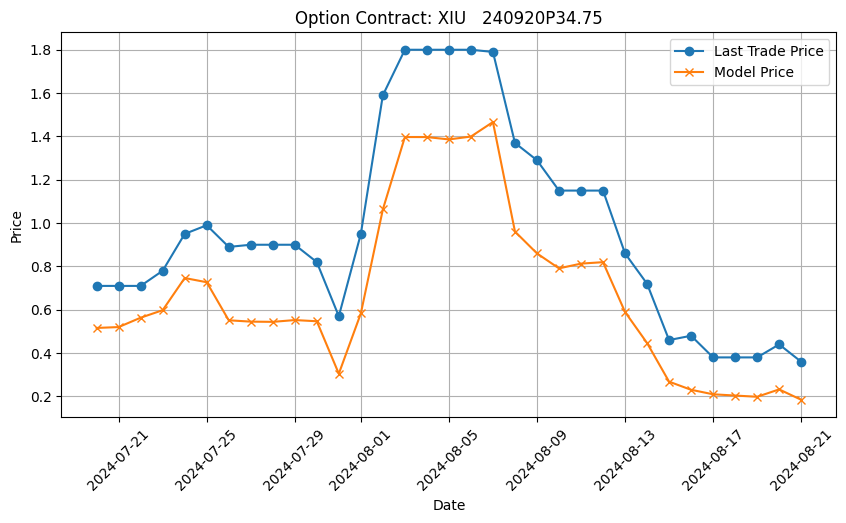

In [46]:
import matplotlib.pyplot as plt

# Choose a contract to plot
contract = "XIU   240920P34.75"  # Replace with an actual contract symbol from your data
df_contract = puts_monthly[puts_monthly["contract_symbol"] == contract].sort_values("query_date")

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(df_contract.index, df_contract["last_trade_price"], label="Last Trade Price", marker="o")
plt.plot(df_contract.index, df_contract["model_price"], label="Model Price", marker="x")

# Formatting
plt.xlabel("Date")
plt.ylabel("Price")
plt.title(f"Option Contract: {contract}")
plt.legend()
plt.grid()
plt.xticks(rotation=45)

plt.show()

c:\Users\viraj\OneDrive\Desktop\Apex Projects\apexenv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


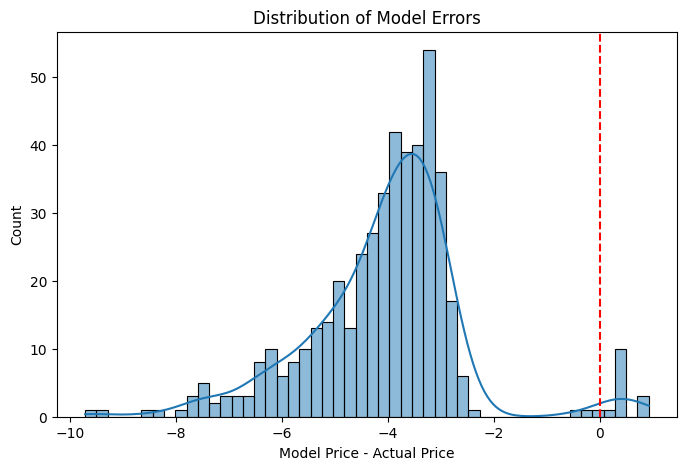

In [53]:
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.histplot(np.log(puts_monthly["model_price"] - puts_monthly["last_trade_price"]), bins=50, kde=True)

plt.xlabel("Model Price - Actual Price")
plt.ylabel("Count")
plt.title("Distribution of Model Errors")
plt.axvline(0, color="red", linestyle="--")  # Perfect prediction line
plt.show()